In [1]:
import math
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, MultipleLocator
from matplotlib.markers import MarkerStyle
from matplotlib.collections import PathCollection

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["axes.unicode_minus"] = False

DATA_PATH = "Q-RMR Data.xlsx"
FEATURE_COLS = ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF"]
TARGET_COL = "RMR"

SEED = 0

df = pd.read_excel(DATA_PATH)
df = df[FEATURE_COLS + [TARGET_COL]].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

X_all = df[FEATURE_COLS].copy()
y_all = df[TARGET_COL].copy()

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.30, random_state=SEED, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True)

model_ogsa = xgb.XGBRegressor(
    n_estimators=408,
    learning_rate=0.11144016352777018,
    max_depth=3,
    tree_method="hist",
    random_state=437
)
model_ogsa.fit(X_tr.values, y_tr.values)

def calc_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

def one_line(name, y_true, y_pred):
    r2, rmse, mae = calc_metrics(y_true, y_pred)
    return pd.DataFrame({
        "Subset": [name],
        "R2": [r2],
        "RMSE": [rmse],
        "MAE": [mae]
    })

metrics_df = pd.concat([
    one_line("Train", y_tr, model_ogsa.predict(X_tr)),
    one_line("Validation", y_val, model_ogsa.predict(X_val)),
    one_line("Test", y_te, model_ogsa.predict(X_te))
], ignore_index=True)

X_tr_df = X_tr.copy()
feature_cols = list(X_tr_df.columns)
n_features = len(feature_cols)

display(metrics_df)

,Subset,R2,RMSE,MAE
0,Train,0.9911,0.6224,0.3317
1,Validation,0.9506,1.6067,0.8097
2,Test,0.9382,1.9031,0.7752


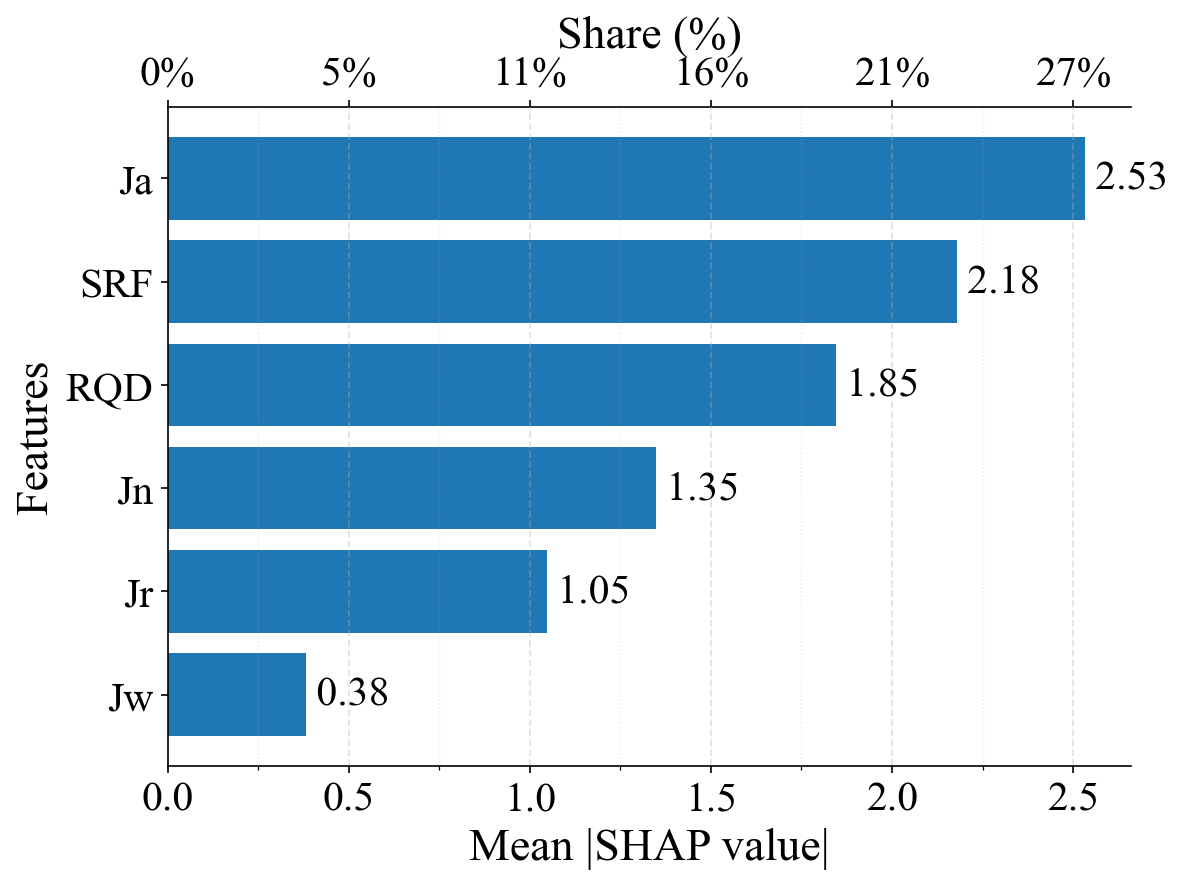

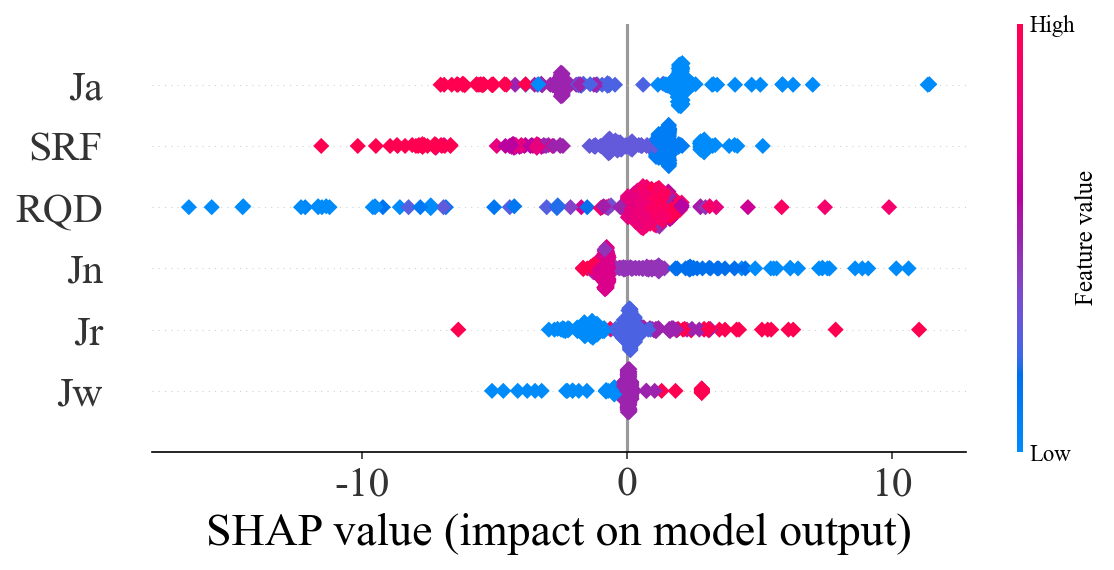

In [2]:
explainer = shap.TreeExplainer(model_ogsa, feature_names=feature_cols)
shap_values = np.array(explainer.shap_values(X_tr_df))
expected_value = explainer.expected_value

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_names = np.array(feature_cols)
share_pct = mean_abs_shap / mean_abs_shap.sum() * 100.0

order_idx = np.argsort(-mean_abs_shap)
vals = mean_abs_shap[order_idx]
pcts = share_pct[order_idx]
names = feat_names[order_idx]

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.barh(names, vals)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|", fontsize=22)
ax.set_ylabel("Features", fontsize=22)
ax.grid(axis="x", which="major", linestyle="--", alpha=0.35, linewidth=0.9)
ax.grid(axis="x", which="minor", linestyle=":", alpha=0.25, linewidth=0.7)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="x", which="both", labelsize=20)
ax.tick_params(axis="y", which="both", labelsize=20)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

def to_pct(x, pos):
    total = mean_abs_shap.sum()
    return f"{x / total * 100:.0f}%"

ax_top = ax.secondary_xaxis("top", functions=(lambda x: x, lambda x: x))
ax_top.set_xlabel("Share (%)", fontsize=22)
ax_top.xaxis.set_major_formatter(FuncFormatter(to_pct))
ax_top.tick_params(axis="x", which="both", labelsize=20)

for y, v in zip(range(len(vals)), vals):
    ax.text(v, y, f" {v:.2f}", va="center", ha="left", fontsize=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 12), dpi=150)
shap.summary_plot(shap_values, X_tr_df, plot_type="dot", show=False)

ax = plt.gca()
diamond = MarkerStyle("D")
diamond_path = diamond.get_path().transformed(diamond.get_transform())

for coll in ax.collections:
    if isinstance(coll, PathCollection):
        try:
            coll.set_paths([diamond_path])
            sizes = coll.get_sizes()
            if sizes is not None and len(sizes):
                coll.set_sizes(np.full_like(sizes, 30.0, dtype=float))
            else:
                coll.set_sizes([30.0])
        except Exception:
            pass

ax.tick_params(axis="x", which="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=22)

yticks = ax.get_yticks()
ylabs = [t.get_text() for t in ax.get_yticklabels()]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabs, fontsize=20)

plt.tight_layout()
plt.show()

,Feature 1,Feature 2,Mean |SHAP interaction|,Share (%)
0,RQD,Jr,0.2646,13.6087
1,RQD,Ja,0.2472,12.7134
2,Jn,SRF,0.2087,10.7379
3,RQD,SRF,0.1889,9.7145
4,Jr,Ja,0.1568,8.0640
5,RQD,Jn,0.1539,7.9190
6,Ja,SRF,0.1242,6.3903
7,Jn,Jr,0.1139,5.8592
8,Jn,Ja,0.1127,5.7974
9,Jr,SRF,0.1124,5.7803


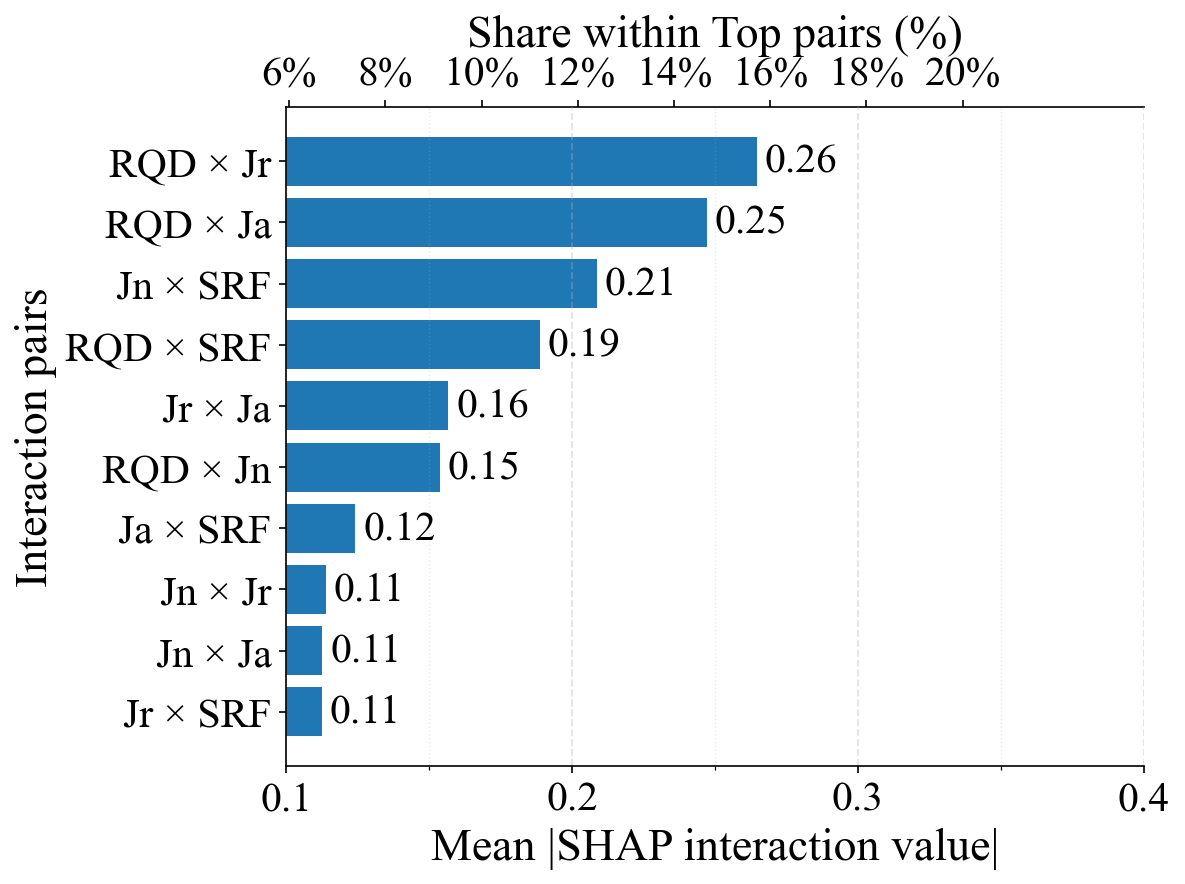

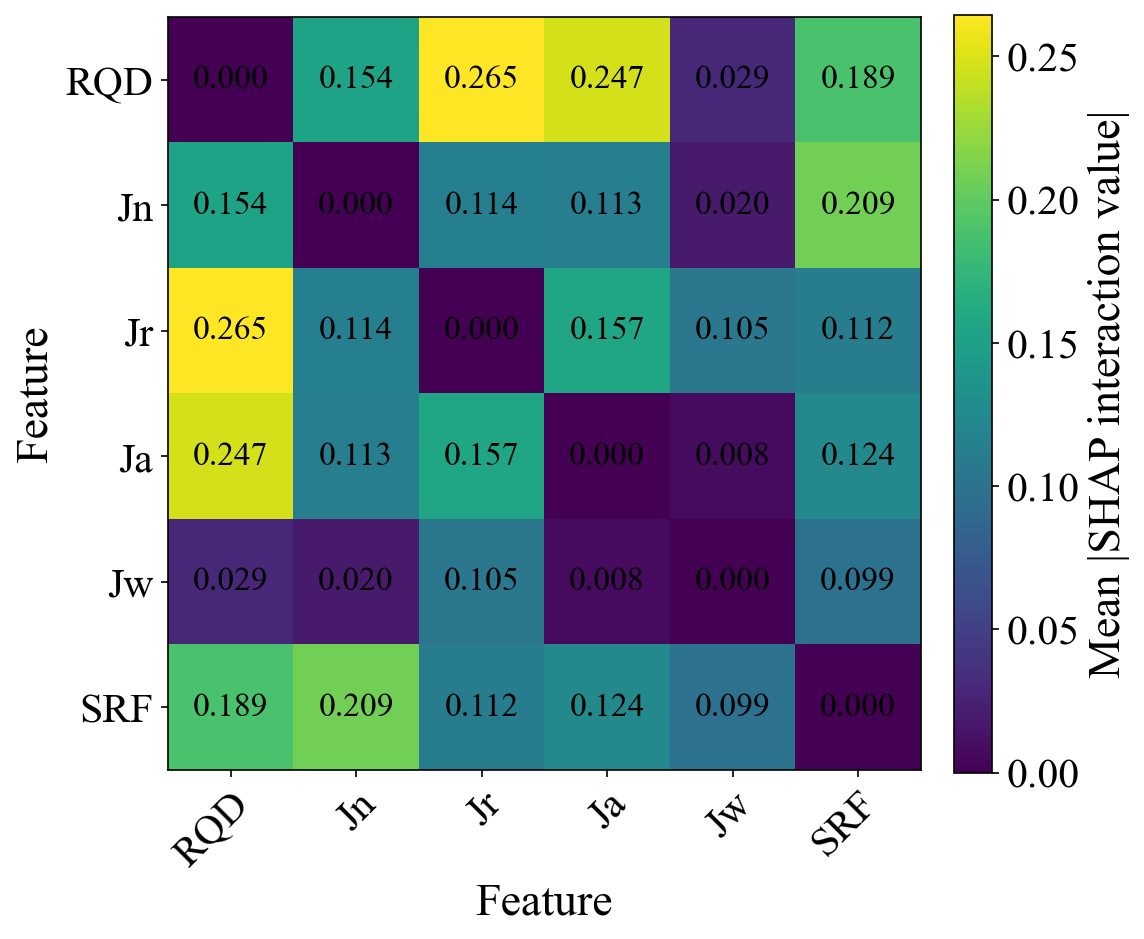

Top SHAP interaction pairs:
1. RQD × Jr : 0.2646 (13.61%)
2. RQD × Ja : 0.2472 (12.71%)
3. Jn × SRF : 0.2087 (10.74%)
4. RQD × SRF : 0.1889 (9.71%)
5. Jr × Ja : 0.1568 (8.06%)
6. RQD × Jn : 0.1539 (7.92%)


In [3]:
explainer_inter = shap.TreeExplainer(model_ogsa, feature_names=feature_cols)
shap_values_inter = np.array(explainer_inter.shap_values(X_tr_df))
shap_inter = np.array(explainer_inter.shap_interaction_values(X_tr_df))

inter_mat = np.abs(shap_inter).mean(axis=0)
inter_mat_offdiag = inter_mat.copy()
np.fill_diagonal(inter_mat_offdiag, 0.0)

pairs = []
for i in range(n_features):
    for j in range(i + 1, n_features):
        pairs.append((feature_cols[i], feature_cols[j], inter_mat_offdiag[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
df_inter_rank = pd.DataFrame(pairs_sorted, columns=["Feature 1", "Feature 2", "Mean |SHAP interaction|"])
df_inter_rank["Share (%)"] = df_inter_rank["Mean |SHAP interaction|"] / df_inter_rank["Mean |SHAP interaction|"].sum() * 100

display(df_inter_rank)

TOP_K = 10
top_df = df_inter_rank.head(TOP_K).copy()
top_df["Pair"] = top_df["Feature 1"] + " × " + top_df["Feature 2"]

labels = top_df["Pair"].tolist()
values = top_df["Mean |SHAP interaction|"].tolist()

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.barh(labels, values)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP interaction value|", fontsize=22)
ax.set_ylabel("Interaction pairs", fontsize=22)
ax.grid(axis="x", which="major", linestyle="--", alpha=0.35, linewidth=0.9)
ax.grid(axis="x", which="minor", linestyle=":", alpha=0.25, linewidth=0.7)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="x", which="both", labelsize=20)
ax.tick_params(axis="y", which="both", labelsize=20)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

top_total = np.sum(values)

def top_pct(x, pos):
    return f"{x / top_total * 100:.0f}%" if top_total > 0 else "0%"

ax_top = ax.secondary_xaxis("top", functions=(lambda x: x, lambda x: x))
ax_top.set_xlabel("Share within Top pairs (%)", fontsize=22)
ax_top.xaxis.set_major_formatter(FuncFormatter(top_pct))
ax_top.tick_params(axis="x", which="both", labelsize=20)

xmax = max(values) if len(values) > 0 else 1.0
pad = 0.01 * xmax if xmax > 0 else 0.01
for y, v in zip(range(len(values)), values):
    ax.text(v + pad, y, f"{v:.2f}", va="center", ha="left", fontsize=20)

x_left = 0.1
x_right = xmax * 1.18 if xmax > 0 else 1.0
if x_right <= x_left:
    x_right = x_left + 0.1

ax.set_xlim(x_left, x_right)
bottom_step = 0.1
bottom_ticks = np.arange(x_left, x_right + bottom_step, bottom_step)
ax.set_xticks(bottom_ticks)

if top_total > 0:
    top_pct_start = 0.06 * top_total
    top_pct_step = 0.02 * top_total
    top_ticks = np.arange(top_pct_start, x_right + top_pct_step, top_pct_step)
    top_ticks = top_ticks[top_ticks >= x_left]
    ax_top.set_xticks(top_ticks)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 6.4), dpi=150)
im = ax.imshow(inter_mat_offdiag, aspect="equal")

ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, fontsize=20)
ax.set_yticklabels(feature_cols, fontsize=20)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{inter_mat_offdiag[i, j]:.3f}", ha="center", va="center", fontsize=16)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean |SHAP interaction value|", fontsize=22)
cbar.ax.tick_params(labelsize=20)

ax.set_xlabel("Feature", fontsize=22)
ax.set_ylabel("Feature", fontsize=22)

plt.tight_layout()
plt.show()

TOP_K_TEXT = 6
print("Top SHAP interaction pairs:")
for idx, row in df_inter_rank.head(TOP_K_TEXT).iterrows():
    print(
        f"{idx + 1}. {row['Feature 1']} × {row['Feature 2']} : "
        f"{row['Mean |SHAP interaction|']:.4f} "
        f"({row['Share (%)']:.2f}%)"
    )

In [4]:
feat_idx = {f: i for i, f in enumerate(feature_cols)}

y_pred_tr = model_ogsa.predict(X_tr_df)

df_pointwise = X_tr_df.copy()
df_pointwise["RMR_true"] = y_tr.values
df_pointwise["RMR_pred"] = y_pred_tr
df_pointwise["residual"] = df_pointwise["RMR_pred"] - df_pointwise["RMR_true"]

for f in feature_cols:
    df_pointwise[f"phi_{f}"] = shap_values_inter[:, feat_idx[f]]

for i in range(n_features):
    for j in range(i + 1, n_features):
        f1 = feature_cols[i]
        f2 = feature_cols[j]
        df_pointwise[f"phi_{f1}x{f2}"] = shap_inter[:, i, j]

display(df_pointwise.head())

pair_phi = {}
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        f1 = feature_cols[i]
        f2 = feature_cols[j]
        pair_phi[(f1, f2)] = np.asarray(shap_inter)[:, i, j]

def summarize_phi(phi_vec):
    phi_vec = np.asarray(phi_vec).astype(float)
    abs_phi = np.abs(phi_vec)

    q25, q50, q75 = np.percentile(phi_vec, [25, 50, 75])
    iqr = q75 - q25

    abs_q25, abs_q50, abs_q75 = np.percentile(abs_phi, [25, 50, 75])
    abs_iqr = abs_q75 - abs_q25

    pos_ratio = float(np.mean(phi_vec > 0))
    neg_ratio = float(np.mean(phi_vec < 0))
    zero_ratio = float(np.mean(phi_vec == 0))

    return {
        "mean(phi)": float(np.mean(phi_vec)),
        "std(phi)": float(np.std(phi_vec, ddof=1)),
        "median(phi)": float(np.median(phi_vec)),
        "IQR(phi)": float(iqr),
        "min(phi)": float(np.min(phi_vec)),
        "max(phi)": float(np.max(phi_vec)),
        "mean(|phi|)": float(np.mean(abs_phi)),
        "std(|phi|)": float(np.std(abs_phi, ddof=1)),
        "median(|phi|)": float(np.median(abs_phi)),
        "IQR(|phi|)": float(abs_iqr),
        "max(|phi|)": float(np.max(abs_phi)),
        "pos_ratio": pos_ratio,
        "neg_ratio": neg_ratio,
        "zero_ratio": zero_ratio
    }

summary_rows = []
for (a, b), phi_vec in pair_phi.items():
    row = {"pair": f"{a} × {b}"}
    row.update(summarize_phi(phi_vec))
    summary_rows.append(row)

df_inter_summary = pd.DataFrame(summary_rows).sort_values("mean(|phi|)", ascending=False).reset_index(drop=True)
display(df_inter_summary)

KEY_PAIRS = ["RQD × Jn", "Jr × Ja", "Jw × SRF"]
df_inter_summary_key = df_inter_summary[df_inter_summary["pair"].isin(KEY_PAIRS)].copy()
df_inter_summary_key = df_inter_summary_key.sort_values("mean(|phi|)", ascending=False).reset_index(drop=True)
display(df_inter_summary_key)

,RQD,Jn,Jr,Ja,Jw,SRF,RMR_true,RMR_pred,residual,phi_RQD,...,phi_JnxJr,phi_JnxJa,phi_JnxJw,phi_JnxSRF,phi_JrxJa,phi_JrxJw,phi_JrxSRF,phi_JaxJw,phi_JaxSRF,phi_JwxSRF
221,90.0000,12,1.5000,2.0000,1.0000,2.5000,51.3000,51.0998,-0.2002,0.9777,...,-0.0104,-0.0465,0.0019,-0.1918,-0.0469,0.0276,0.0003,0.0006,-0.0193,-0.0374
276,91.0000,12,1.5000,2.0000,1.0000,2.5000,51.4000,51.2882,-0.1118,1.1512,...,-0.0104,-0.0486,0.0019,-0.1915,-0.0482,0.0276,0.0003,0.0006,-0.0193,-0.0362
191,15.0000,9,3.0000,2.0000,1.0000,2.5000,34.0000,34.5149,0.5149,-16.5376,...,-1.1569,-0.0186,0.0104,-0.1289,0.1320,0.0122,-0.2846,0.0004,-0.0205,-0.1401
239,78.0000,15,1.0000,2.0000,1.0000,1.5000,51.1900,50.8119,-0.3781,0.4091,...,-0.2406,0.0597,0.0006,-0.0039,0.2103,-0.0906,0.0081,0.0006,-0.0972,-0.0931
394,80.0000,12,1.5000,4.0000,1.0000,1.5000,48.6000,48.6958,0.0958,0.2430,...,-0.0130,0.0075,0.0021,0.1062,0.1191,0.0304,0.0252,0.0003,0.1406,-0.0925


,pair,mean(phi),std(phi),median(phi),IQR(phi),min(phi),max(phi),mean(|phi|),std(|phi|),median(|phi|),IQR(|phi|),max(|phi|),pos_ratio,neg_ratio,zero_ratio
0,RQD × Jr,-0.0352,0.5239,-0.1104,0.2878,-4.7488,4.2369,0.2646,0.4533,0.1518,0.0946,4.7488,0.4281,0.5719,0.0000
1,RQD × Ja,0.0208,0.5171,-0.0349,0.1921,-3.2997,2.9309,0.2472,0.4545,0.0989,0.1381,3.2997,0.4026,0.5974,0.0000
2,Jn × SRF,-0.0914,0.3686,0.0573,0.2290,-2.1373,1.0279,0.2087,0.3170,0.0746,0.1318,2.1373,0.6134,0.3866,0.0000
3,RQD × SRF,0.0729,0.3499,0.0462,0.1517,-0.4893,1.8969,0.1889,0.3033,0.0812,0.1572,1.8969,0.5879,0.4121,0.0000
4,Jr × Ja,0.0793,0.1820,0.1366,0.2370,-0.6210,0.5505,0.1568,0.1215,0.1495,0.1672,0.6210,0.6550,0.3450,0.0000
5,RQD × Jn,0.0123,0.3128,0.0346,0.1218,-2.2051,1.5689,0.1539,0.2725,0.0589,0.1007,2.2051,0.6134,0.3866,0.0000
6,Ja × SRF,-0.0230,0.1840,-0.0347,0.2114,-0.7538,0.8615,0.1242,0.1375,0.0972,0.0878,0.8615,0.3866,0.6134,0.0000
7,Jn × Jr,-0.0689,0.2765,-0.0066,0.0438,-1.3776,0.7479,0.1139,0.2612,0.0302,0.0447,1.3776,0.4633,0.5367,0.0000
8,Jn × Ja,-0.0099,0.2505,-0.0380,0.0715,-0.9365,2.2878,0.1127,0.2238,0.0587,0.0598,2.2878,0.4249,0.5751,0.0000
9,Jr × SRF,-0.0483,0.2087,-0.0035,0.0949,-0.9578,0.6490,0.1124,0.1823,0.0294,0.0527,0.9578,0.4824,0.5176,0.0000


,pair,mean(phi),std(phi),median(phi),IQR(phi),min(phi),max(phi),mean(|phi|),std(|phi|),median(|phi|),IQR(|phi|),max(|phi|),pos_ratio,neg_ratio,zero_ratio
0,Jr × Ja,0.0793,0.1820,0.1366,0.2370,-0.6210,0.5505,0.1568,0.1215,0.1495,0.1672,0.6210,0.6550,0.3450,0.0000
1,RQD × Jn,0.0123,0.3128,0.0346,0.1218,-2.2051,1.5689,0.1539,0.2725,0.0589,0.1007,2.2051,0.6134,0.3866,0.0000
2,Jw × SRF,-0.0632,0.1392,-0.0901,0.1132,-0.8806,0.6582,0.0988,0.1165,0.0903,0.0621,0.8806,0.2524,0.7476,0.0000


In [5]:
LABEL_FONTSIZE = 34
TICK_FONTSIZE = 34

def set_all_text_tnr(ax):
    ax.xaxis.label.set_fontname("Times New Roman")
    ax.xaxis.label.set_fontsize(LABEL_FONTSIZE)
    ax.yaxis.label.set_fontname("Times New Roman")
    ax.yaxis.label.set_fontsize(LABEL_FONTSIZE)
    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE, direction="in")
    ax.tick_params(axis="both", which="minor", labelsize=TICK_FONTSIZE, direction="in")
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontname("Times New Roman")
        t.set_fontsize(TICK_FONTSIZE)

def convert_scatter_to_diamond(ax, size=90):
    diamond_path = MarkerStyle("D").get_path().transformed(MarkerStyle("D").get_transform())
    for coll in ax.collections:
        if hasattr(coll, "set_paths"):
            try:
                coll.set_paths([diamond_path])
                coll.set_sizes([size])
            except Exception:
                pass

def format_colorbar(fig, cbar_major_step=2):
    if len(fig.axes) < 2:
        return
    cax = fig.axes[-1]
    cax.tick_params(axis="y", which="major", labelsize=TICK_FONTSIZE, direction="in")
    cax.tick_params(axis="y", which="minor", labelsize=TICK_FONTSIZE, direction="in")
    for t in cax.get_yticklabels():
        t.set_fontname("Times New Roman")
        t.set_fontsize(TICK_FONTSIZE)
    cax.yaxis.set_major_locator(MultipleLocator(cbar_major_step))
    cax.yaxis.set_minor_locator(MultipleLocator(cbar_major_step / 2))

def show_shap_dependence_plot(ind, interaction_index, shap_values, X_df, feature_names, figsize=(9, 5.5), diamond_size=90, x_major_step=None, cbar_major_step=2):
    shap.dependence_plot(
        ind=ind,
        shap_values=shap_values,
        features=X_df,
        feature_names=feature_names,
        interaction_index=interaction_index,
        show=False
    )

    fig = plt.gcf()
    ax = plt.gca()
    fig.set_size_inches(figsize[0], figsize[1], forward=True)

    if x_major_step is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major_step))

    convert_scatter_to_diamond(ax, size=diamond_size)
    set_all_text_tnr(ax)
    format_colorbar(fig, cbar_major_step=cbar_major_step)

    plt.tight_layout()
    plt.show()

,Feature 1,Feature 2,Mean |SHAP interaction|,Share (%)
0,RQD,Jr,0.2646,13.6087
1,RQD,Ja,0.2472,12.7134
2,Jn,SRF,0.2087,10.7379
3,RQD,SRF,0.1889,9.7145
4,Jr,Ja,0.1568,8.0640
5,RQD,Jn,0.1539,7.9190


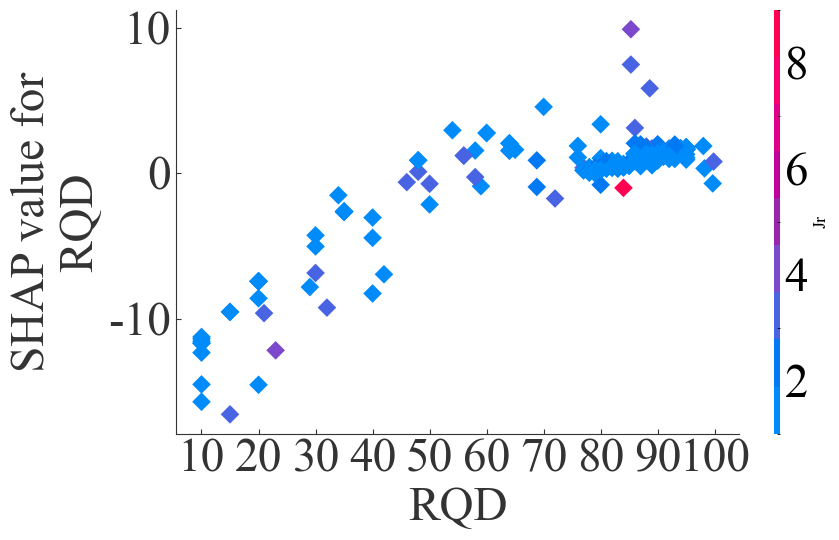

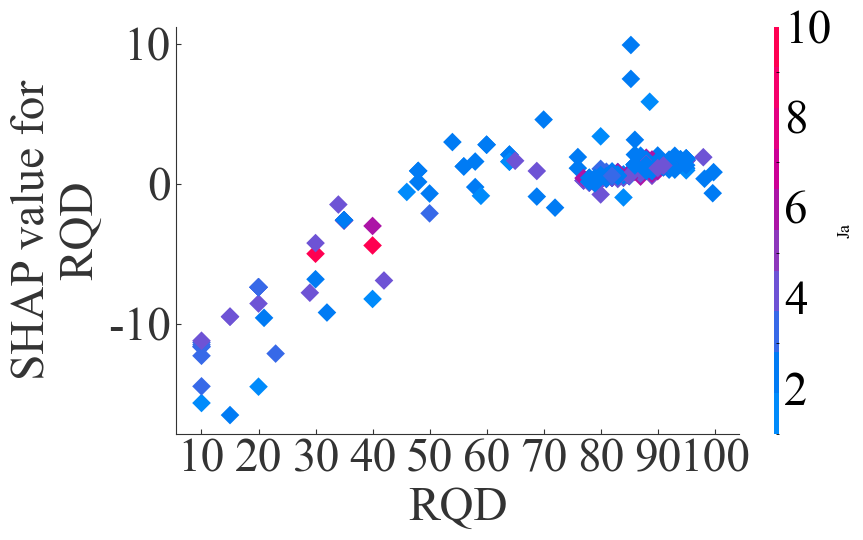

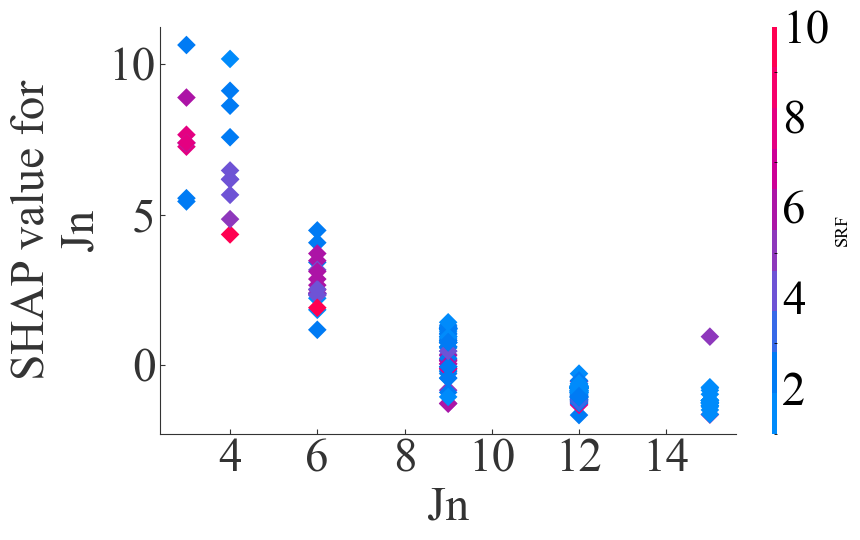

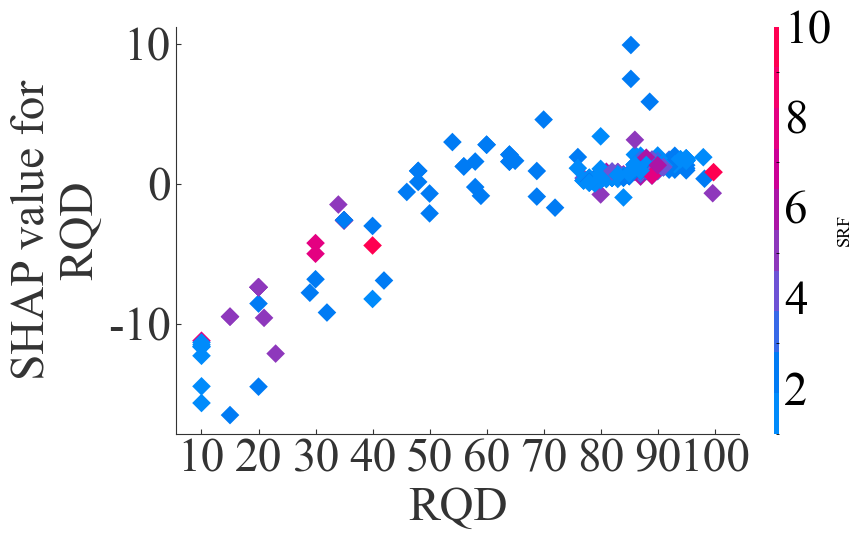

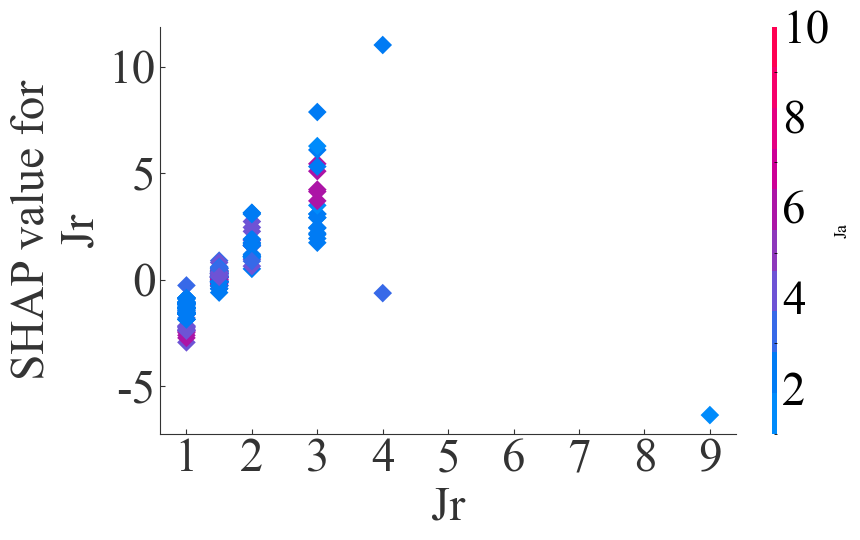

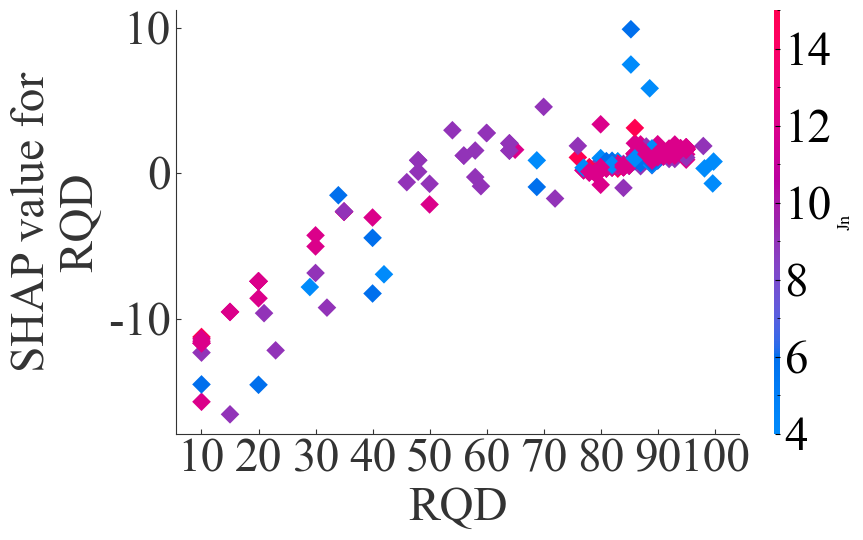

In [6]:
x_major_step_map = {
    "RQD": 10,
    "Jn": 2,
    "Jr": 1,
    "Ja": 1,
    "Jw": 0.2,
    "SRF": 2
}

TOP_N = 6
top6_pairs = df_inter_rank.head(TOP_N).copy()
display(top6_pairs)

for _, row in top6_pairs.iterrows():
    ind = row["Feature 1"]
    interaction_index = row["Feature 2"]
    show_shap_dependence_plot(
        ind=ind,
        interaction_index=interaction_index,
        shap_values=shap_values_inter,
        X_df=X_tr_df,
        feature_names=list(X_tr_df.columns),
        diamond_size=90,
        x_major_step=x_major_step_map.get(ind, None)
    )

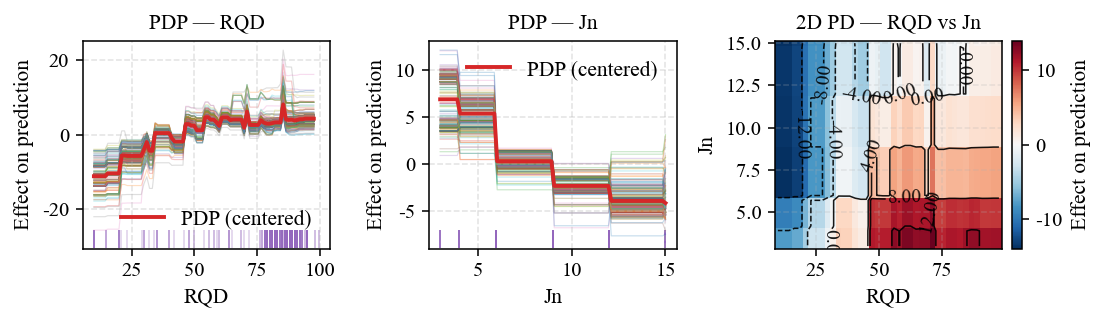

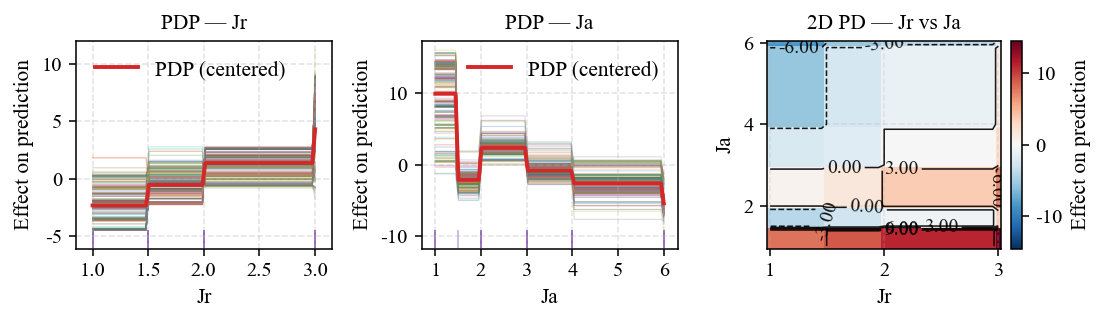

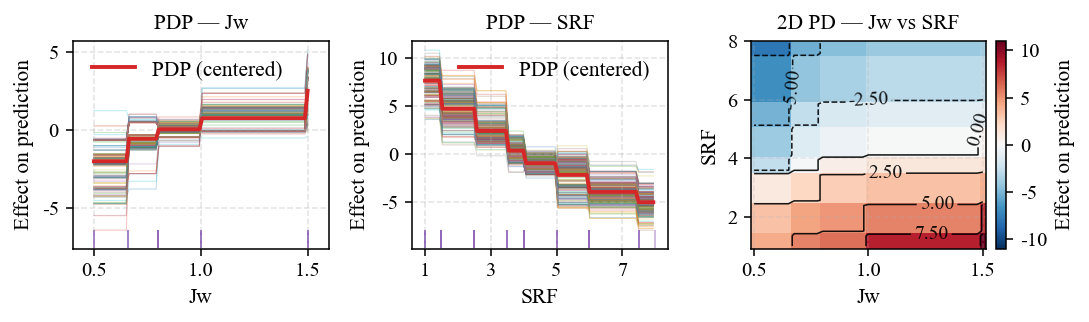

In [27]:
LABEL_FONTSIZE = 11
TICK_FONTSIZE = 10.5
TITLE_FONTSIZE = 11
LEGEND_FONTSIZE = 11
CONTOUR_FONTSIZE = 10
CB_LABEL_FSIZE = 11
CB_TICK_FSIZE = 10.5

Q_LOW, Q_HIGH = 0.01, 0.99
GRID_1D = 80
GRID_2D = 41
PDP_CENTER = True
DRAW_ICE = True
ICE_SUBSAMPLE = 1000
RUG_ALPHA = 0.25

FIGSIZE_ROW = (8, 2.4)
DPI = 140

CMAP_2D_DEFAULT = "cividis"
USE_DIVERGING = True
DIVERGING_CMAP = "RdBu_r"
SHARE_VLIM = None

PDP_XLIM_MAP = {
    "Jr": (0.85, 3.15),
    "Ja": (0.7, 6.3),
    "Jw": (0.4, 1.6),
    "SRF": (0.6, 8.4)
}

PDP_XSTEP_MAP = {
    "Jr": 0.5,
    "Ja": 1.0
}

def pdp_1d(model, X_df, feat, grid, center=True):
    X = X_df.values.copy()
    j = list(X_df.columns).index(feat)
    z = np.empty_like(grid, dtype=float)
    for i, v in enumerate(grid):
        X[:, j] = v
        z[i] = model.predict(X).mean()
    if center:
        z = z - z.mean()
    return z

def ice_1d(model, X_df, feat, grid, subsample=400, random_state=437, center=True):
    rng = np.random.RandomState(random_state)
    if subsample is not None and len(X_df) > subsample:
        idx = rng.choice(len(X_df), subsample, replace=False)
        Xsub = X_df.iloc[idx].copy()
    else:
        Xsub = X_df.copy()

    X = Xsub.values
    j = list(Xsub.columns).index(feat)
    ice = np.empty((len(Xsub), len(grid)), dtype=float)
    for i, v in enumerate(grid):
        X_tmp = X.copy()
        X_tmp[:, j] = v
        ice[:, i] = model.predict(X_tmp)
    if center:
        ice = ice - ice.mean(axis=1, keepdims=True)
    return ice

def pd2d(model, X_df, f1, f2, q_low=0.01, q_high=0.99, grid_n=41, center=True):
    X = X_df.copy()
    j1 = list(X.columns).index(f1)
    j2 = list(X.columns).index(f2)

    x1 = X[f1].values
    x2 = X[f2].values
    lo1, hi1 = np.quantile(x1, q_low), np.quantile(x1, q_high)
    lo2, hi2 = np.quantile(x2, q_low), np.quantile(x2, q_high)
    g1 = np.linspace(lo1, hi1, grid_n)
    g2 = np.linspace(lo2, hi2, grid_n)

    Z = np.empty((grid_n, grid_n), dtype=float)
    base = X.values.copy()
    for i, v1 in enumerate(g1):
        for j, v2 in enumerate(g2):
            arr = base.copy()
            arr[:, j1] = v1
            arr[:, j2] = v2
            Z[i, j] = model.predict(arr).mean()
    if center:
        Z = Z - Z.mean()
    return g1, g2, Z

def centers_to_edges(g):
    if len(g) == 1:
        step = 1.0
    else:
        step = g[1] - g[0]
    edges = np.concatenate(([g[0] - step / 2], 0.5 * (g[:-1] + g[1:]), [g[-1] + step / 2]))
    return edges

def plot_pdp(ax, model, X_df, feat, q_low=Q_LOW, q_high=Q_HIGH, grid_n=GRID_1D, center=PDP_CENTER, draw_ice=DRAW_ICE, ice_subsample=ICE_SUBSAMPLE, rug_alpha=RUG_ALPHA):
    x = X_df[feat].values
    lo, hi = np.quantile(x, q_low), np.quantile(x, q_high)
    grid = np.linspace(lo, hi, grid_n)

    if draw_ice:
        ice = ice_1d(model, X_df, feat, grid, subsample=ice_subsample, center=center)
        ax.plot(grid, ice.T, lw=0.6, alpha=0.25, zorder=1)

    z = pdp_1d(model, X_df, feat, grid, center=center)
    ax.plot(grid, z, lw=2.0, label="PDP (centered)" if center else "PDP", zorder=3)
    ax.plot(x, np.full_like(x, ax.get_ylim()[0]), "|", alpha=rug_alpha, markersize=9, zorder=0)

    if feat in PDP_XLIM_MAP:
        ax.set_xlim(PDP_XLIM_MAP[feat])

    if feat in PDP_XSTEP_MAP:
        ax.xaxis.set_major_locator(MultipleLocator(PDP_XSTEP_MAP[feat]))

    if feat == "SRF":
        ax.set_xticks(np.arange(1, 9, 2))

    ax.set_xlabel(feat, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Effect on prediction", fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", which="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, linestyle="--", alpha=0.35)

    if draw_ice:
        ax.legend(frameon=False, loc="best", fontsize=LEGEND_FONTSIZE)

from matplotlib.colors import TwoSlopeNorm

def plot_pd2d(ax, model, X_df, f1, f2, q_low=Q_LOW, q_high=Q_HIGH, grid_n=GRID_2D, center=True, cmap_name=CMAP_2D_DEFAULT, use_diverging=USE_DIVERGING, diverging_cmap=DIVERGING_CMAP, share_vlim=SHARE_VLIM):
    g1, g2, Z = pd2d(model, X_df, f1, f2, q_low=q_low, q_high=q_high, grid_n=grid_n, center=center)

    if use_diverging:
        if share_vlim is None:
            m = np.nanmax(np.abs(Z))
            vmin, vmax = -m, m
        else:
            vmin, vmax = share_vlim
        cmap = plt.get_cmap(diverging_cmap)
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    else:
        cmap = plt.get_cmap(cmap_name)
        if share_vlim is not None:
            vmin, vmax = share_vlim
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = None

    Xe, Ye = centers_to_edges(g1), centers_to_edges(g2)
    pcm = ax.pcolormesh(Xe, Ye, Z.T, shading="auto", cmap=cmap, norm=norm)
    cs = ax.contour(g1, g2, Z.T, colors="k", linewidths=0.8, alpha=0.9, levels=8)
    ax.clabel(cs, inline=True, fontsize=CONTOUR_FONTSIZE, fmt="%.2f")

    ax.set_xlabel(f1, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(f2, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", which="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, linestyle="--", alpha=0.25)
    return pcm

fig1, axes1 = plt.subplots(1, 3, figsize=FIGSIZE_ROW, dpi=DPI)
plot_pdp(axes1[0], model_ogsa, X_tr_df, "RQD")
axes1[0].set_title("PDP — RQD", fontsize=TITLE_FONTSIZE)
plot_pdp(axes1[1], model_ogsa, X_tr_df, "Jn")
axes1[1].set_title("PDP — Jn", fontsize=TITLE_FONTSIZE)
pcm = plot_pd2d(axes1[2], model_ogsa, X_tr_df, "RQD", "Jn", center=True)
axes1[2].set_title("2D PD — RQD vs Jn", fontsize=TITLE_FONTSIZE)
cbar = fig1.colorbar(pcm, ax=axes1[2], fraction=0.046, pad=0.04)
cbar.set_label("Effect on prediction", fontsize=CB_LABEL_FSIZE)
cbar.ax.tick_params(labelsize=CB_TICK_FSIZE)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=FIGSIZE_ROW, dpi=DPI)
plot_pdp(axes2[0], model_ogsa, X_tr_df, "Jr")
axes2[0].set_title("PDP — Jr", fontsize=TITLE_FONTSIZE)
plot_pdp(axes2[1], model_ogsa, X_tr_df, "Ja")
axes2[1].set_title("PDP — Ja", fontsize=TITLE_FONTSIZE)
pcm = plot_pd2d(axes2[2], model_ogsa, X_tr_df, "Jr", "Ja", center=True)
axes2[2].set_title("2D PD — Jr vs Ja", fontsize=TITLE_FONTSIZE)
cbar = fig2.colorbar(pcm, ax=axes2[2], fraction=0.046, pad=0.04)
cbar.set_label("Effect on prediction", fontsize=CB_LABEL_FSIZE)
cbar.ax.tick_params(labelsize=CB_TICK_FSIZE)
plt.tight_layout()
plt.show()

fig3, axes3 = plt.subplots(1, 3, figsize=FIGSIZE_ROW, dpi=DPI)
plot_pdp(axes3[0], model_ogsa, X_tr_df, "Jw")
axes3[0].set_title("PDP — Jw", fontsize=TITLE_FONTSIZE)
plot_pdp(axes3[1], model_ogsa, X_tr_df, "SRF")
axes3[1].set_title("PDP — SRF", fontsize=TITLE_FONTSIZE)
pcm = plot_pd2d(axes3[2], model_ogsa, X_tr_df, "Jw", "SRF", center=True)
axes3[2].set_title("2D PD — Jw vs SRF", fontsize=TITLE_FONTSIZE)
cbar = fig3.colorbar(pcm, ax=axes3[2], fraction=0.046, pad=0.04)
cbar.set_label("Effect on prediction", fontsize=CB_LABEL_FSIZE)
cbar.ax.tick_params(labelsize=CB_TICK_FSIZE)
plt.tight_layout()
plt.show()

In [8]:
Q_LOW, Q_HIGH = 0.01, 0.99
GRID_1D = 80
GRID_2D = 41
PDP_CENTER = True
CONTOUR_LEVELS = 8

pairs_2d = [("RQD", "Jn"), ("Jr", "Ja"), ("Jw", "SRF")]
features_1d = ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF"]

def path_length(seg):
    if seg is None or len(seg) < 2:
        return 0.0
    dx = np.diff(seg[:, 0])
    dy = np.diff(seg[:, 1])
    return float(np.sum(np.hypot(dx, dy)))

def compute_1d_pdp_raw_and_summary(model, X_df, feat, q_low=Q_LOW, q_high=Q_HIGH, grid_n=GRID_1D, center=PDP_CENTER):
    x = X_df[feat].values
    lo, hi = np.quantile(x, q_low), np.quantile(x, q_high)
    grid = np.linspace(lo, hi, grid_n)
    pdp_vals = pdp_1d(model, X_df, feat, grid, center=center)

    slopes = np.diff(pdp_vals) / np.diff(grid)
    abs_slopes = np.abs(slopes)
    idx_steep = int(np.argmax(abs_slopes))

    raw_df = pd.DataFrame({
        "feature": feat,
        "grid_x": grid,
        "pdp": pdp_vals
    })

    summary = {
        "feature": feat,
        "q_low": q_low,
        "q_high": q_high,
        "grid_n": grid_n,
        "grid_min": float(grid.min()),
        "grid_max": float(grid.max()),
        "pdp_min": float(pdp_vals.min()),
        "pdp_max": float(pdp_vals.max()),
        "amplitude": float(pdp_vals.max() - pdp_vals.min()),
        "mean_abs_slope": float(np.mean(abs_slopes)),
        "max_abs_slope": float(np.max(abs_slopes)),
        "steepest_interval_left": float(grid[idx_steep]),
        "steepest_interval_right": float(grid[idx_steep + 1]),
        "steepest_interval_midpoint": float(0.5 * (grid[idx_steep] + grid[idx_steep + 1])),
        "steepest_interval_slope": float(slopes[idx_steep])
    }
    return raw_df, pd.DataFrame([summary])

def compute_2d_nonadditivity(model, X_df, f1, f2, q_low=Q_LOW, q_high=Q_HIGH, grid_n=GRID_2D, center=PDP_CENTER):
    g1, g2, Z = pd2d(model, X_df, f1, f2, q_low=q_low, q_high=q_high, grid_n=grid_n, center=center)

    pdp_f1 = pdp_1d(model, X_df, f1, g1, center=center)
    pdp_f2 = pdp_1d(model, X_df, f2, g2, center=center)

    additive = pdp_f1[:, None] + pdp_f2[None, :]
    nonadd = Z - additive

    idx_peak = np.unravel_index(np.argmax(Z), Z.shape)
    mean_abs_nonadd = float(np.mean(np.abs(nonadd)))
    pdp_range = float(np.max(Z) - np.min(Z))
    pai = float(mean_abs_nonadd / pdp_range) if pdp_range != 0 else np.nan

    metrics = pd.DataFrame([{
        "pair": f"{f1} × {f2}",
        "feature_1": f1,
        "feature_2": f2,
        "q_low": q_low,
        "q_high": q_high,
        "grid_n": grid_n,
        "pai": pai,
        "mean_abs_nonadditivity": mean_abs_nonadd,
        "p95_abs_nonadditivity": float(np.quantile(np.abs(nonadd), 0.95)),
        "max_abs_nonadditivity": float(np.max(np.abs(nonadd))),
        "peak_x": float(g1[idx_peak[0]]),
        "peak_y": float(g2[idx_peak[1]]),
        "peak_pdp": float(Z[idx_peak]),
        "pdp_min": float(np.min(Z)),
        "pdp_max": float(np.max(Z)),
        "pdp_range": pdp_range
    }])

    rows = []
    for i, x1 in enumerate(g1):
        for j, x2 in enumerate(g2):
            rows.append({
                "pair": f"{f1} × {f2}",
                "feature_1": f1,
                "feature_2": f2,
                f1: float(x1),
                f2: float(x2),
                "pdp_2d": float(Z[i, j]),
                "pdp_additive": float(additive[i, j]),
                "nonadditivity": float(nonadd[i, j])
            })
    grid_df = pd.DataFrame(rows)

    return g1, g2, Z, nonadd, metrics, grid_df

def extract_contour_paths(g1, g2, Z, f1, f2, levels=CONTOUR_LEVELS):
    fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
    cs = ax.contour(g1, g2, Z.T, levels=levels, colors="k", linewidths=0.8, alpha=0.9)

    points_records = []
    summary_records = []

    for level_idx, level in enumerate(cs.levels):
        segs = cs.allsegs[level_idx]
        for seg_idx, seg in enumerate(segs):
            if seg is None or len(seg) == 0:
                continue

            seg = np.asarray(seg)
            n_points = int(len(seg))
            is_closed = bool(np.allclose(seg[0], seg[-1])) if n_points >= 2 else False
            path_len = path_length(seg)

            summary_records.append({
                "pair": f"{f1} × {f2}",
                "feature_1": f1,
                "feature_2": f2,
                "level_idx": int(level_idx),
                "level_value": float(level),
                "segment_idx": int(seg_idx),
                "n_points": n_points,
                "is_closed": is_closed,
                "path_length": path_len,
                "x_min": float(np.min(seg[:, 0])),
                "x_max": float(np.max(seg[:, 0])),
                "y_min": float(np.min(seg[:, 1])),
                "y_max": float(np.max(seg[:, 1]))
            })

            for point_idx, (xv, yv) in enumerate(seg):
                points_records.append({
                    "pair": f"{f1} × {f2}",
                    "feature_1": f1,
                    "feature_2": f2,
                    "level_idx": int(level_idx),
                    "level_value": float(level),
                    "segment_idx": int(seg_idx),
                    "point_idx": int(point_idx),
                    "x": float(xv),
                    "y": float(yv)
                })

    plt.close(fig)
    return pd.DataFrame(points_records), pd.DataFrame(summary_records)

all_pdp1d_raw = []
all_pdp1d_summary = []

for feat in features_1d:
    raw_df, summary_df = compute_1d_pdp_raw_and_summary(
        model_ogsa, X_tr_df, feat,
        q_low=Q_LOW, q_high=Q_HIGH,
        grid_n=GRID_1D, center=PDP_CENTER
    )
    all_pdp1d_raw.append(raw_df)
    all_pdp1d_summary.append(summary_df)

pdp1d_raw_df = pd.concat(all_pdp1d_raw, axis=0, ignore_index=True)
pdp1d_summary_df = pd.concat(all_pdp1d_summary, axis=0, ignore_index=True)

all_pair_metrics = []
pair_grid_dfs = {}
pair_contour_points = {}
pair_contour_summary = {}

for f1, f2 in pairs_2d:
    g1, g2, Z, nonadd, metrics_df, grid_df = compute_2d_nonadditivity(
        model_ogsa, X_tr_df, f1, f2,
        q_low=Q_LOW, q_high=Q_HIGH,
        grid_n=GRID_2D, center=PDP_CENTER
    )

    contour_points_df, contour_summary_df = extract_contour_paths(
        g1, g2, Z, f1, f2, levels=CONTOUR_LEVELS
    )

    all_pair_metrics.append(metrics_df)
    pair_name = f"{f1}_{f2}"
    pair_grid_dfs[pair_name] = grid_df
    pair_contour_points[pair_name] = contour_points_df
    pair_contour_summary[pair_name] = contour_summary_df

pair_metrics_df = pd.concat(all_pair_metrics, axis=0, ignore_index=True)

display(pdp1d_summary_df)
display(pair_metrics_df)

for pair_name, df_grid in pair_grid_dfs.items():
    print(pair_name)
    display(df_grid.head())

for pair_name, df_sum in pair_contour_summary.items():
    print(pair_name)
    display(df_sum.head())

for pair_name, df_pts in pair_contour_points.items():
    print(pair_name)
    display(df_pts.head())

,feature,q_low,q_high,grid_n,grid_min,grid_max,pdp_min,pdp_max,amplitude,mean_abs_slope,max_abs_slope,steepest_interval_left,steepest_interval_right,steepest_interval_midpoint,steepest_interval_slope
0,RQD,0.0100,0.9900,80,10.0000,97.6400,-11.0948,8.1516,19.2464,0.6441,4.3631,84.3276,85.4370,84.8823,4.3631
1,Jn,0.0100,0.9900,80,3.0000,15.0000,-4.1464,6.9188,11.0652,0.9221,33.5289,5.8861,6.0380,5.9620,-33.5289
2,Jr,0.0100,0.9900,80,1.0000,3.0000,-2.3270,4.2932,6.6202,3.3101,115.7642,2.9747,3.0000,2.9873,115.7642
3,Ja,0.0100,0.9900,80,1.0000,6.0000,-5.4210,9.9264,15.3474,4.8638,190.3475,1.4430,1.5063,1.4747,-190.3475
4,Jw,0.0100,0.9900,80,0.5000,1.5000,-2.0219,2.5212,4.5432,4.5432,139.3916,1.4873,1.5000,1.4937,139.3916
5,SRF,0.0100,0.9900,80,1.0000,7.9400,-5.0032,7.6151,12.6183,1.8182,32.9903,1.4392,1.5271,1.4832,-32.9903


,pair,feature_1,feature_2,q_low,q_high,grid_n,pai,mean_abs_nonadditivity,p95_abs_nonadditivity,max_abs_nonadditivity,peak_x,peak_y,peak_pdp,pdp_min,pdp_max,pdp_range
0,RQD × Jn,RQD,Jn,0.0100,0.9900,41,0.0470,1.3027,3.9066,4.3444,71.3480,3.0000,13.7762,-13.9226,13.7762,27.6988
1,Jr × Ja,Jr,Ja,0.0100,0.9900,41,0.0165,0.3834,0.8590,1.0261,3.0000,1.0000,14.6111,-8.5941,14.6111,23.2052
2,Jw × SRF,Jw,SRF,0.0100,0.9900,41,0.0194,0.3686,1.3532,1.5931,1.5000,1.0000,11.0403,-7.9523,11.0403,18.9926


RQD_Jn


,pair,feature_1,feature_2,RQD,Jn,pdp_2d,pdp_additive,nonadditivity
0,RQD × Jn,RQD,Jn,10.0000,3.0000,-7.8844,-4.0224,-3.8620
1,RQD × Jn,RQD,Jn,10.0000,3.3000,-7.8844,-4.0224,-3.8620
2,RQD × Jn,RQD,Jn,10.0000,3.6000,-7.8844,-4.0224,-3.8620
3,RQD × Jn,RQD,Jn,10.0000,3.9000,-7.8844,-4.0224,-3.8620
4,RQD × Jn,RQD,Jn,10.0000,4.2000,-9.6460,-5.5359,-4.1101


Jr_Ja


...

,pair,feature_1,feature_2,level_idx,level_value,segment_idx,point_idx,x,y
0,RQD × Jn,RQD,Jn,1,-12.0000,0,0,19.7590,15.0000
1,RQD × Jn,RQD,Jn,1,-12.0000,0,1,19.5148,14.7000
2,RQD × Jn,RQD,Jn,1,-12.0000,0,2,19.5148,14.4000
3,RQD × Jn,RQD,Jn,1,-12.0000,0,3,19.5148,14.1000
4,RQD × Jn,RQD,Jn,1,-12.0000,0,4,19.5148,13.8000


Jr_Ja


,pair,feature_1,feature_2,level_idx,level_value,segment_idx,point_idx,x,y
0,Jr × Ja,Jr,Ja,1,-6.0000,0,0,1.4911,6.0000
1,Jr × Ja,Jr,Ja,1,-6.0000,0,1,1.4500,5.8879
2,Jr × Ja,Jr,Ja,1,-6.0000,0,2,1.4000,5.8879
3,Jr × Ja,Jr,Ja,1,-6.0000,0,3,1.3500,5.8879
4,Jr × Ja,Jr,Ja,1,-6.0000,0,4,1.3000,5.8879


Jw_SRF


,pair,feature_1,feature_2,level_idx,level_value,segment_idx,point_idx,x,y
0,Jw × SRF,Jw,SRF,1,-7.5000,0,0,0.6545,7.9400
1,Jw × SRF,Jw,SRF,1,-7.5000,0,1,0.6545,7.7665
2,Jw × SRF,Jw,SRF,1,-7.5000,0,2,0.6545,7.5930
3,Jw × SRF,Jw,SRF,1,-7.5000,0,3,0.6500,7.5204
4,Jw × SRF,Jw,SRF,1,-7.5000,0,4,0.6250,7.5204
